<a href="https://colab.research.google.com/github/wesleylelo/CDIA_AI_COLAB/blob/develop/AG_DEAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#######################################################################
#######################################################################
#Instituição: SENAI - CIMATEC
#Curso: Ciência de Dados e Inteligência Artificial (CDIA)
#Disciplina: Inteligência Artificial II
#Autor: Carlos Fernando Arraz | Data: Fevereiro, 2024
#UA02 - Roteiro de Prática Guiada: Utilização de algoritmos de busca em
#                                  problemas de engenharia e logística
######################################################################
######################################################################

---

INSTRUÇÕES GERAIS:

---



1 - Realize uma cópia deste arquivo em seu repositório pessoal para iniciar a prática (usar o e-mail institucional para isso);

2 - Reveja o conteúdo teórico e os exemplos práticos vistos até agora na graduação para pontecializar o aprendizado;

3 -Leia a teoria e acompanhe o script python linha a linha e seus comentários (execute as células com **shift + ENTER** ou botão play à esquerda de cada comando/bloco de código), estudando as estruturas, as partes do algoritmo e a lógica proposta;

4 - Execute, modifique, teste e experimente o conteúdo ao máximo para internalizar o conhecimento; e

5- Compare os resultados com bibliotecas de machine learning consagradas no desenvolvimento de soluções em AI.

#Este roteiro tem como objetivo apresentar a implementação de uma Algoritmo Genético (AG) com da biblioteca DEAP (Distributed Evolutionary Algorithms in Python) para este fim, que é uma das técnicas mais usadas em python 🐍 para desenvolver soluções que usem a teoria dos AGs.



# PARTE I: Instalar e importar módulos da biblioteca DEAP

In [1]:
#Intalar a biblioteca
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 3.5 MB/s eta 0:00:00


In [2]:
#Importar módulos da biblioteca DEAP
from deap import creator, base, tools, algorithms

#PARTE II - Construir os elementos que fazem parte da teoria dos algoritmo genéticos

**Minimização**

Definir os objetivos da função de aptidão, que para este caso temos um problema de minimização com único objetivo, a biblioteca DEAP precisa instanciar o creator:

creator.create("FitnessMin", base.Fitness, weights = (-1.0, ) )

**Representar os indivíduos**

Precisamos definir os cromossomos que irão povoar nosso algorimo, e para isso usaremos o módulo creator mais uma vez, como segue:

creator.create("EstrIndividuo", tipo, fitness= creator.FitnessMin)

**Registro de genes**

Precisamos agora regsitrar como registramos um cromossomo, gene a gene. No nosso caso, temos 4 genes que formam o cromossomo. Para isso, o DEAP precisa saber como representamos o indivíduo, como a seguir:

toolbox = base.Toolbox()

n = 4  #tamanho dos genes

toolbox.register("Genes", np.random.permutation, n)



E por fim, precisamos registrar:

toolbox.register("Individuos", tools.initIterate, creator.Estrindividuo, toolbox.Genes)

Agora, precisamos definir a população:

toolbox.regsiter("Populacao", tools.initRepeat, list, toolbox.Individuos)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:

toolbox = base.Toolbox()
n = 4

creator.create("FitnessMin", base.Fitness, weights = (-1.0, ))
creator.create("EstrIndividuo", list, fitness = creator.FitnessMin)

In [5]:
toolbox.register("Genes", np.random.permutation, n)
toolbox.register("Individuos", tools.initIterate, creator.EstrIndividuo, toolbox.Genes)

In [6]:
toolbox.register("Populacao", tools.initRepeat, list, toolbox.Individuos)

In [7]:
pop = toolbox.Populacao(n=5)

In [ ]:
pop

[[3, 1, 0, 2], [2, 3, 0, 1], [0, 3, 2, 1], [1, 0, 2, 3], [3, 1, 0, 2]]

Definir operadores genéticos, tais como cruzamento e mutação

In [8]:
toolbox.register("mate", tools.cxPartialyMatched)

Crossover

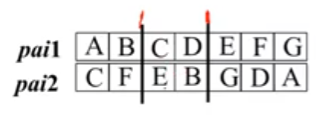

Como resultado, temos como filho:

filho 1 : A B E B E F G
filho 2 : C F C D G D A




Mutação

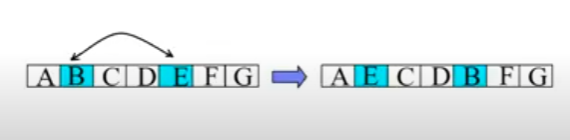

In [9]:
toolbox.register("mutate", tools.mutShuffleIndexes, indpb = 0.1)

## Seleção

In [11]:
toolbox.register("select", tools.selTournament, tournsize = 2)

## Aptidão

In [10]:
dist = [[0,7,9,2],
        [4,0,3,7],
        [6,7,0,8],
        [2,3,8,0]
        ]

In [ ]:
dist

[[0, 7, 9, 2], [4, 0, 3, 7], [6, 7, 0, 8], [2, 3, 8, 0]]

In [12]:
def aptidao(individuo):
  f = 0
  for i in range(n-1):
    loc1 = individuo[i]
    loc2 = individuo[i+1]
    f = f + dist[loc1][loc2]
  f = f + dist[loc2][individuo[0]]  #volta para origem
  return f,


In [13]:
toolbox.register("evaluate", aptidao)

## Elistismo

In [14]:
def estatisticaElitismo(individuo):
  return individuo.fitness.values

In [15]:
elitismo = tools.Statistics(estatisticaElitismo)
elitismo.register('mean', np.mean)
elitismo.register('max', np.max)
elitismo.register('min', np.min)

Hall da fama

In [16]:
hallFama = tools.HallOfFame(1)

## Execução do algoritmo

In [17]:
result, log = algorithms.eaSimple(pop,
                                  toolbox,
                                  cxpb = 0.8,
                                  mutpb=0.1,
                                  stats = elitismo,
                                  ngen = 500,
                                  halloffame=hallFama,
                                  verbose=True
                                  )

gen	nevals	mean	max	min
0  	5     	20.2	28 	14 
1  	4     	19.4	28 	14 
2  	4     	16.4	20 	14 
3  	4     	15.2	20 	14 
4  	4     	15.2	20 	14 
5  	4     	15.2	20 	14 
6  	2     	14  	14 	14 
7  	3     	15.4	21 	14 
8  	4     	14  	14 	14 
9  	4     	14  	14 	14 
10 	4     	14  	14 	14 
11 	4     	15.4	21 	14 
12 	4     	15.4	21 	14 
13 	4     	14  	14 	14 
14 	2     	14  	14 	14 
15 	4     	14  	14 	14 
16 	2     	14  	14 	14 
17 	4     	14  	14 	14 
18 	4     	14  	14 	14 
19 	2     	14  	14 	14 
20 	2     	14  	14 	14 
21 	2     	14  	14 	14 
22 	2     	14  	14 	14 
23 	4     	14  	14 	14 
24 	4     	16.8	28 	14 
25 	4     	14  	14 	14 
26 	4     	14  	14 	14 
27 	3     	15.2	20 	14 
28 	4     	14  	14 	14 
29 	5     	16.2	25 	14 
30 	2     	14  	14 	14 
31 	4     	14  	14 	14 
32 	4     	14  	14 	14 
33 	4     	14  	14 	14 
34 	4     	15.4	21 	14 
35 	4     	16.2	25 	14 
36 	2     	14  	14 	14 
37 	3     	14  	14 	14 
38 	2     	14  	14 	14 
39 	2     	14  	14 	14 
40 	2     	14  	

In [18]:
print(result)

[[np.int64(3), np.int64(1), np.int64(2), np.int64(0)], [np.int64(3), np.int64(1), np.int64(2), np.int64(0)], [np.int64(3), np.int64(1), np.int64(2), np.int64(0)], [np.int64(3), np.int64(1), np.int64(2), np.int64(0)], [np.int64(3), np.int64(1), np.int64(2), np.int64(0)]]


In [20]:
print(hallFama)

[[np.int64(0), np.int64(3), np.int64(1), np.int64(2)]]


In [21]:
melhor = hallFama[0]
print(melhor)
aptidao(melhor)

[np.int64(0), np.int64(3), np.int64(1), np.int64(2)]


(14,)

In [22]:
log

[{'gen': 0,
  'nevals': 5,
  'mean': np.float64(20.2),
  'max': np.float64(28.0),
  'min': np.float64(14.0)},
 {'gen': 1,
  'nevals': 4,
  'mean': np.float64(19.4),
  'max': np.float64(28.0),
  'min': np.float64(14.0)},
 {'gen': 2,
  'nevals': 4,
  'mean': np.float64(16.4),
  'max': np.float64(20.0),
  'min': np.float64(14.0)},
 {'gen': 3,
  'nevals': 4,
  'mean': np.float64(15.2),
  'max': np.float64(20.0),
  'min': np.float64(14.0)},
 {'gen': 4,
  'nevals': 4,
  'mean': np.float64(15.2),
  'max': np.float64(20.0),
  'min': np.float64(14.0)},
 {'gen': 5,
  'nevals': 4,
  'mean': np.float64(15.2),
  'max': np.float64(20.0),
  'min': np.float64(14.0)},
 {'gen': 6,
  'nevals': 2,
  'mean': np.float64(14.0),
  'max': np.float64(14.0),
  'min': np.float64(14.0)},
 {'gen': 7,
  'nevals': 3,
  'mean': np.float64(15.4),
  'max': np.float64(21.0),
  'min': np.float64(14.0)},
 {'gen': 8,
  'nevals': 4,
  'mean': np.float64(14.0),
  'max': np.float64(14.0),
  'min': np.float64(14.0)},
 {'gen': 9

In [23]:
menores = log.select('min')
maiores = log.select('max')
media = log.select('mean')

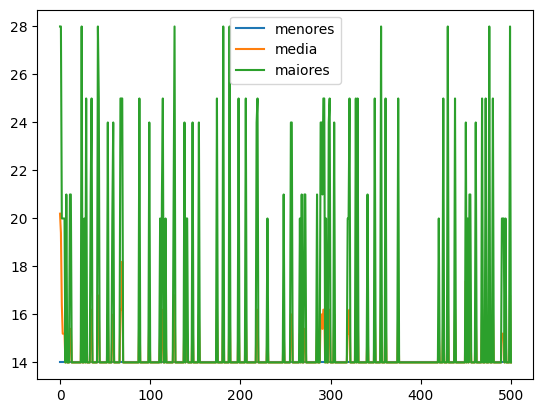

In [24]:
plt.plot(menores, label='menores')
plt.plot(media, label='media')
plt.plot(maiores, label='maiores')
plt.legend()

Referências:

[1] PEREIRA, Eduardo. Computação Evolucionária: Aplique os algoritmos genéticos com Python e Numpy. Casa do Código, 2020.

[2] FACELI, Katti; et al. Inteligência artificial: uma abordagem de aprendizado de máquina. Rio de Janeiro: Grupo GEN, 2021. E-book. ISBN 9788521637509.

[3] Géron, A. (2022). Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow. " O'Reilly Media, Inc.".

[4] NETTO, Amilcar; MACIEL, Francisco. Python para data science e machine learning descomplicado. Rio de Janeiro: Alta Books, 2021. E-book. ISBN 9786555203172.

[5] Fonte online AWS. O que é ajuste de hiperparâmetros. Página online https://aws.amazon.com/pt/what-is/hyperparameter-tuning/  acessada em 29/01/2024.

[6] Fonte online Scikit-Learn. Tuning the hyper-parameters of an estimator. Página online https://scikit-learn.org/stable/modules/grid_search.html#tuning-the-hyper-parameters-of-an-estimator acessada em 30/01/2024.